In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt


# Projeto 4 - Sinais e Sistemas em Tempo Discreto - 2024/01
# Identificação
## Nome: Leonardo Pereira Côrtes
## Matrícula: 200030582

# Funções utilizadas.

Coloque abaixo as funções desenvolvidas para este projeto.

In [2]:
#Código das funções utilizadas.

# Questão 1

Considere um sinal $x\left[n\right]$ com 16 amostras:

$$
x\left[n\right] = \left\{ 1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 6, 5, 4, 3, 2, 1\right\}
$$


## Questão 1a (1.0 ponto)

Calcule a DFT do sinal através da equação:

$$
X\left[k\right] = \sum_{n = 0}^{N-1} x\left[n\right] W_{N}^{kn}
$$

com $W_{N} = e^{-\frac{2 \pi}{N}}$.

In [3]:
#Resposta da questão 1a
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 6, 5, 4, 3, 2, 1])
N = len(x)

X = np.zeros(N, dtype=complex)

W_N = np.exp(-2j * np.pi / N)

for k in range(N):
	for n in range(N):
		X[k] += x[n] * (W_N ** (k * n))

# Imprimir o resultado
print("DFT do sinal x[n]:")
print(X)

DFT do sinal x[n]:
[ 7.20000000e+01+0.00000000e+00j -2.52741424e+01-5.02733949e+00j
  1.22124533e-15+2.22044605e-16j -2.23982881e+00-1.49660576e+00j
  8.88178420e-16+0.00000000e+00j -4.46462692e-01-6.68178638e-01j
  4.44089210e-16+5.55111512e-16j -3.95661299e-02-1.98912367e-01j
  2.55351296e-15-1.29540443e-14j -3.95661299e-02+1.98912367e-01j
 -2.49800181e-14+1.22124533e-14j -4.46462692e-01+6.68178638e-01j
 -3.07732800e-14-3.61932706e-14j -2.23982881e+00+1.49660576e+00j
 -3.69704267e-14-5.17363929e-14j -2.52741424e+01+5.02733949e+00j]


## Questão 1b (1.0 ponto)

Considere a separação do sinal $x\left[n\right]$ em suas amostras pares e ímpares, $x_e\left[n\right]$ e $x_o\left[n\right]$, respectivamente. 

Calcule a DFT do sinal $x\left[n\right]$ através da equação:

$$
\hat{X}\left[k\right] = X_e\left[k\right] + W_{N}^{k} X_o\left[k\right]
$$

Compare as duas DFTs e calcule o erro médio absoluto (MAE) entre as DFTs calculadas pelas duas formas:

$$
MAE = \sum_{i = 0}^{N-1} \left| X\left[i\right] - \hat{X}\left[i\right]\right|
$$

In [4]:
def DFT(x):
	N = len(x)
	X = np.zeros(N, dtype=complex)
	for k in range(N):
		for n in range(N):
			X[k] += x[n] * np.e**(-2j * np.pi * k * n / N)
	return X

X_e = DFT(x[::2])
X_o = DFT(x[1::2])

X_e_concat = np.concatenate((X_e, X_e)) # X[0] = X[8], X[2] = X[10], ...
X_o_concat = np.concatenate((X_o, X_o)) # X[1] = X[9], X[3] = X[11], ...

X_hat = np.zeros(N, dtype=complex)
for k in range(N):
	X_hat[k] = X_e_concat[k] + W_N**k * X_o_concat[k]
 
print("DFT calculada de forma iterativa:")
print(X_hat)

MAE = 0
for i in range(N):
	MAE += abs(X[i] - X_hat[i])

print("\nErro Médio Absoluto (MAE):", MAE)


DFT calculada de forma iterativa:
[ 7.20000000e+01+0.00000000e+00j -2.52741424e+01-5.02733949e+00j
 -1.15149714e-16+5.41014870e-17j -2.23982881e+00-1.49660576e+00j
 -2.44929360e-16-2.44929360e-16j -4.46462692e-01-6.68178638e-01j
 -6.00321710e-15+6.65412847e-15j -3.95661299e-02-1.98912367e-01j
  0.00000000e+00+1.59872116e-14j -3.95661299e-02+1.98912367e-01j
  1.77001034e-16+3.89987723e-16j -4.46462692e-01+6.68178638e-01j
  2.44929360e-16-2.44929360e-16j -2.23982881e+00+1.49660576e+00j
 -2.08276894e-14-7.54230689e-15j -2.52741424e+01+5.02733949e+00j]

Erro Médio Absoluto (MAE): 4.3782698263663495e-13


# Questão 2

O arquivo "potencia.txt" contém dados da envoltória real de um tom senoidal amostrado a uma taxa de $200$ amostras / segundo. Para a separação do desvanecimento em larga escala é necessário filtrar esse sinal com um filtro passa-baixas com frequência de corte em torno de $5$ Hz.


## Questão 2a (1.0  ponto)

Projete um filtro digital com a especificação desejada. Podem ser utilizadas as funções de design de filtro da PySDR (https://pysdr.org/content/filters.html), da própria biblioteca scipy (https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html) ou mesmo bibliotecas web (http://t-filter.engineerjs.com/) . Plote a resposta em frequência e a resposta ao impulso do filtro projetado. 

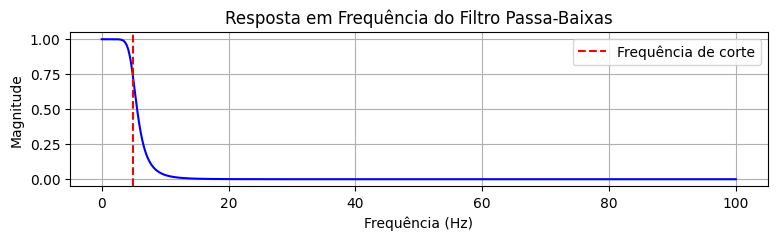

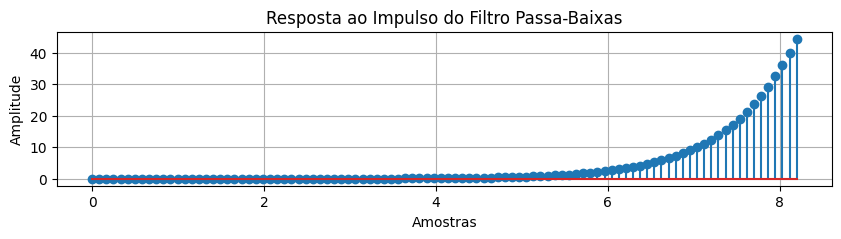

In [5]:
fs = 200
fc = 5

b, a = sp.signal.butter(5, fc, fs=fs, btype='low', analog=False)
w, h = sp.signal.freqz(b, a, fs=fs, worN=8000)

plt.figure(figsize=(9, 2))
plt.plot(w, np.abs(h), 'b')
plt.axvline(fc, color='r', linestyle='--', label='Frequência de corte')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.title('Resposta em Frequência do Filtro Passa-Baixas')
plt.grid()
plt.legend()
plt.show()

t, yout = sp.signal.impulse((b, a))

plt.figure(figsize=(10, 2))
plt.stem(t, yout)
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.title('Resposta ao Impulso do Filtro Passa-Baixas')
plt.grid()
plt.show()


## Questão 2b (1.0 ponto)

Escreva uma função para processar uma janela de $N$ amostras do sinal desejado. $N$ deve ser escolhido em torno de 1 segundo de sinal, aproximadamente. A filtragem deve ser feita no domínio da DFT (pode ser utilizada alguma função para cálculo da fft em Python, como a função fft da biblioteca numpy).

In [6]:
def filtro_passa_baixa(sinal, fs, fc):
	N = len(sinal)
	
	dft = np.fft.fft(sinal)
	freq = np.fft.fftfreq(N, 1/fs)
	
	dft_filtro = np.zeros(N, dtype=complex)
	dft_filtro[np.abs(freq) <= fc] = 1
	
	sinal_filtrado = np.fft.ifft(dft * dft_filtro)
	
	return sinal_filtrado.real

## Questão 2c (1.0  ponto)

Escreva uma função para combinar a saída do processamento de cada janela na saída do sistema, utilizando **um** dos métodos vistos (*overlap and add* ou *overlap and save*). Indique claramente o método escolhido.


In [7]:
sinal = np.loadtxt("potencia.txt")

def overlap_and_add(sinal, janela, sobreposicao, fc, fs):
	N = len(sinal)
 
	overlap_samples = int(janela * sobreposicao)
	step = janela - overlap_samples
	
	sinal_filtrado = np.zeros(N, dtype=complex)
	
	for i in range(0, N, step):
		sinal_filtrado[i:i+janela] += (1/2)*filtro_passa_baixa(sinal[i:i+janela], fs, fc)
  
	return sinal_filtrado.real

## Questão 2d (1.0  ponto)

Plote o sinal de entrada e saída do sistema dado tanto pelo processamento em janelas como pelo processamento do sinal completo. Pode ser utilizada alguma função da biblioteca do python para calcular a saída do sistema usando o sinal completo.

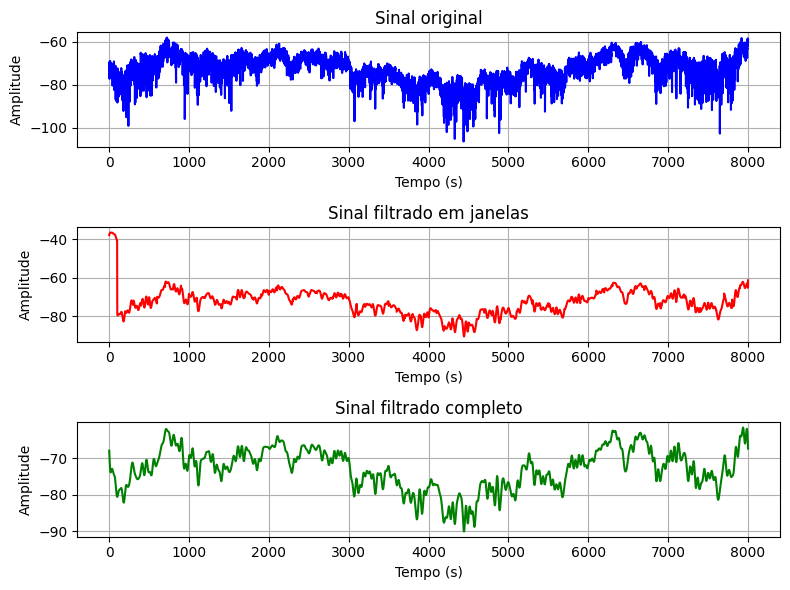

In [8]:
fs = 200
fc = 5
janela = 200
sobreposicao = 0.5

t = list(range(len(sinal)))

plt.figure(figsize=(8, 6))
plt.subplot(3, 1, 1)
plt.plot(t, sinal, 'b')
plt.title("Sinal original")
plt.ylabel('Amplitude')
plt.xlabel('Tempo (s)')
plt.grid()

sinal_filtrado_janela = overlap_and_add(sinal, janela, sobreposicao, fc, fs)

plt.subplot(3, 1, 2)
plt.plot(t, sinal_filtrado_janela, 'r')
plt.title("Sinal filtrado em janelas")
plt.ylabel('Amplitude')
plt.xlabel('Tempo (s)')
plt.grid()

sinal_filtrado_completo = filtro_passa_baixa(sinal, fs, fc)

plt.subplot(3, 1, 3)
plt.plot(t, sinal_filtrado_completo, 'g')
plt.title("Sinal filtrado completo")
plt.ylabel('Amplitude')
plt.xlabel('Tempo (s)')
plt.grid()

plt.tight_layout()
plt.show()

# Questão 3

A equação diferença para um filtro FIR de tamanho $N$ pode ser escrita como:

$$
\begin{align}
	y\left[n\right] &= h_0 x\left[n\right] + h_1 x\left[n-1\right] + h_2 x\left[n-2\right] + h_3 \left[n-3\right] + \ldots + h_{N-1} x\left[n - \left(N- 1\right)\right] \\
	       &= \sum_{k=0}^{N-1} h_k x\left[n - k\right] 
\end{align}
$$

Os coeficientes do filtro, ou \textit{taps}, são expressados usando a variável $h_k$ para enfatizar que os próprios coeficientes representam a resposta ao impulso do filtro. A resposta em frequência do filtro é:

$$
\begin{align}
	H\left( \Omega \right) = \frac{Y\left( \Omega \right)}{X\left( \Omega \right)} = \sum_{k=0}^{N-1} h_k e^{-j \Omega k}
\end{align}
$$

Como $H\left( \Omega \right)$ é uma função com período $2 \pi$ da variável contínua $\Omega$, é suficiente especificar $H\left( \Omega \right)$ em apenas um período $0 \leq \Omega < 2 \pi$. 

Em muitas aplicações, a resposta em magnitude desejada do filtro $\left|H_d \left( \Omega \right)\right|$ é conhecida, mas não os coeficientes $h_k$ do filtro. A questão é, então, determinar os coeficientes do filtro a partir da resposta em magnitude desejada. Podemos fazer isso simplesmente amostrando a resposta em frequência desejada $\left|H_d \left( \Omega \right)\right|$ com $N$ amostras em um período, e então fazendo a DFT inversa dessas amostras (obtendo $h\left[n\right]$). Note que a definição dos coeficientes $h_k$ é suficiente para determinar o sistema do filtro FIR. Além disso, como $H \left( \Omega \right)$ foi obtido amostrando $\left|H_d \left( \Omega \right)\right|$ para algumas frequências, garantimos que a resposta em frequência do filtro projeto será igual a resposta em frequência desejada ao menos nos valores de amostragem. Finalmente, observe que, ao fazer a DFT inversa, alguns coeficientes $h_k$ podem ter uma pequena componente imaginária que deve ser descartada para o projeto de um filtro real. 



## Questão 3a (1.0  ponto)

Considere então um sinal de ECG amostrado a uma taxa de $500$ Hz. Projete um filtro digital FIR através da amostragem de frequência passa-baixas com frequência de corte igual a $50$ Hz. 

Plote a resposta ao impulso $h\left[n\right]$ e a resposta em frequência $H\left(\Omega\right)$ do filtro para $N = 21$, $N = 31$ e $N = 41$. Compare os filtros com a resposta em frequência desejada. 

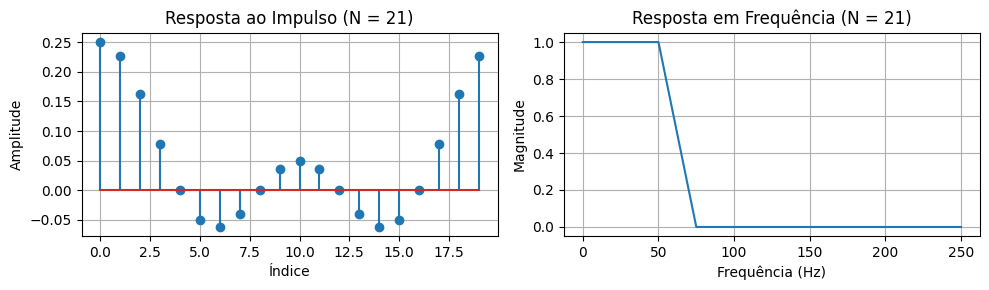

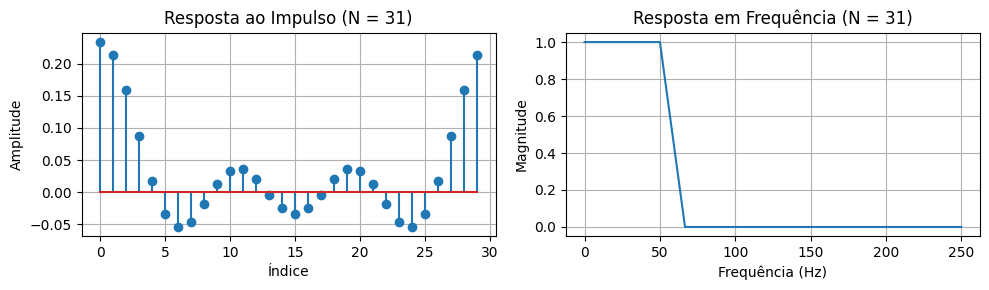

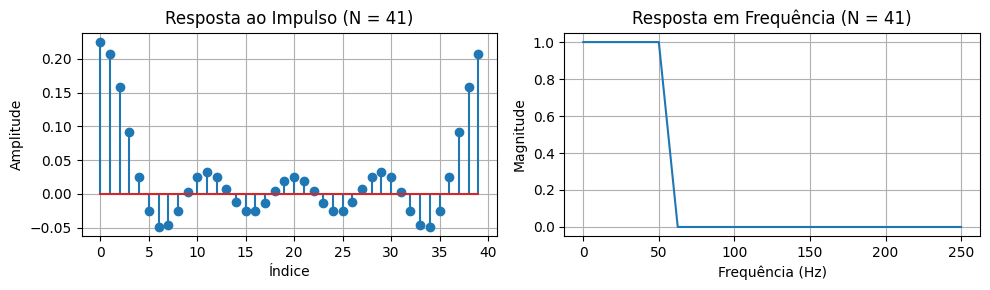

In [9]:
#Resposta da questão 3a
def filtro_fir(fs, fc, N):
	freq = np.linspace(0, fs / 2, N // 2 + 1)
	
	resposta_mag_desejada = np.ones(len(freq))
	resposta_mag_desejada[freq > fc] = 0

	resposta_mag = np.concatenate((resposta_mag_desejada, resposta_mag_desejada[-2:0:-1]))

	h = np.fft.ifft(resposta_mag).real

	return h, freq

fs = 500
fc = 50

h, freq = filtro_fir(fs, fc, 21)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].stem(h)
ax[0].set_title(f'Resposta ao Impulso (N = 21)')
ax[0].set_xlabel('Índice')
ax[0].set_ylabel('Amplitude')
ax[0].grid()

ax[1].plot(freq, np.abs(np.fft.fft(h)[:len(freq)]))
ax[1].set_title(f'Resposta em Frequência (N = 21)')
ax[1].set_xlabel('Frequência (Hz)')
ax[1].set_ylabel('Magnitude')
ax[1].grid()

plt.tight_layout()
plt.show()

h, freq = filtro_fir(fs, fc, 31)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].stem(h)
ax[0].set_title(f'Resposta ao Impulso (N = 31)')
ax[0].set_xlabel('Índice')
ax[0].set_ylabel('Amplitude')
ax[0].grid()

ax[1].plot(freq, np.abs(np.fft.fft(h)[:len(freq)]))
ax[1].set_title(f'Resposta em Frequência (N = 31)')
ax[1].set_xlabel('Frequência (Hz)')
ax[1].set_ylabel('Magnitude')
ax[1].grid()

plt.tight_layout()
plt.show()

h, freq = filtro_fir(fs, fc, 41)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].stem(h)
ax[0].set_title(f'Resposta ao Impulso (N = 41)')
ax[0].set_xlabel('Índice')
ax[0].set_ylabel('Amplitude')
ax[0].grid()

ax[1].plot(freq, np.abs(np.fft.fft(h)[:len(freq)]))
ax[1].set_title(f'Resposta em Frequência (N = 41)')
ax[1].set_xlabel('Frequência (Hz)')
ax[1].set_ylabel('Magnitude')
ax[1].grid()

plt.tight_layout()
plt.show()

## Questão 3b (1.0  ponto)

A resposta ao impulso do filtro do item anterior deveria ser uma função *sinc*, que é uma função com suporte infinito. Porém, a amostragem amostra apenas a parte para $n$ positivo, gerando uma descontinuidade e uma resposta em frequência mais pobre. Uma forma de melhorar essa amostragem é centralizar a função *sinc* - para isso, devemos multiplicar a resposta em frequência do filtro $H\left(\Omega\right)$ por $e^{-j \Omega \frac{\left(N - 1\right)}{2}}$. Utilize essa técnica para gerar novos filtros com $N = 21$, $N = 31$ e $N = 41$. Compare os filtros com os filtros do item anterior com o mesmo tamanho.

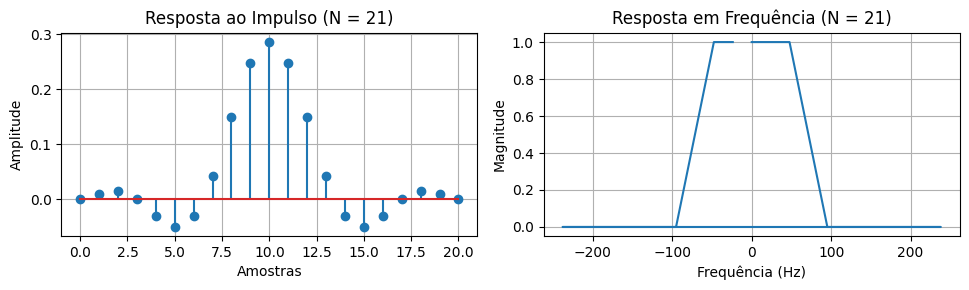

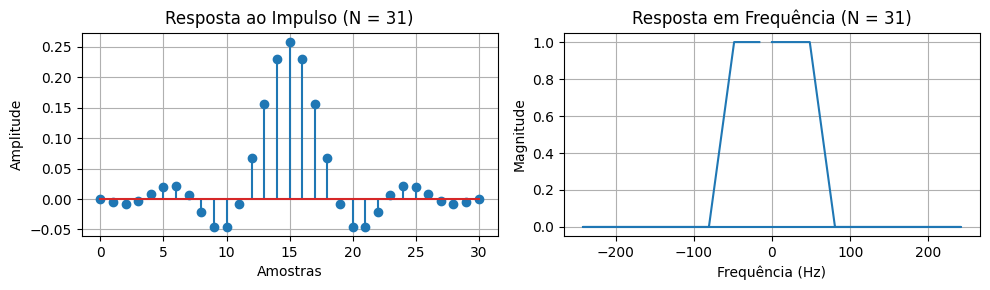

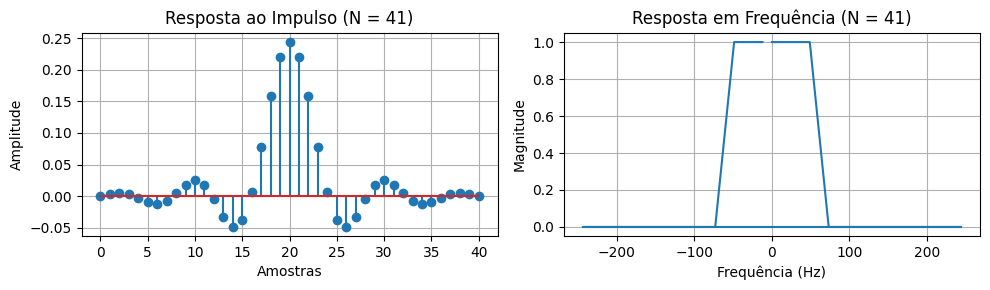

In [10]:
#Resposta da questão 3b
def filtro_fir_centralizado(fs, fc, N):
	freq = np.linspace(0, fs/2, int(N/2) + 1)
	resposta_mag_desejada = np.ones(len(freq))
	resposta_mag_desejada[freq > fc] = 0
	resposta_mag = np.concatenate((resposta_mag_desejada, resposta_mag_desejada[-2::-1]))

	freq = np.fft.fftfreq(N, d=1/fs)
	resposta_mag = resposta_mag * np.exp(-1j * 2 * np.pi * freq * (int((N-1)/2)) / fs)
	resposta_mag = np.clip(resposta_mag, -1, 1)
	h = np.fft.ifft(resposta_mag).real

	return h, freq

fs = 500
fc = 50

N = 21
h, freq = filtro_fir_centralizado(fs, fc, N)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].stem(h)
ax[0].set_title(f'Resposta ao Impulso (N = {N})')
ax[0].set_xlabel('Amostras')
ax[0].set_ylabel('Amplitude')
ax[0].grid()

ax[1].plot(freq, np.abs(np.fft.fft(h)[:len(freq)]))
ax[1].set_title(f'Resposta em Frequência (N = {N})')
ax[1].set_xlabel('Frequência (Hz)')
ax[1].set_ylabel('Magnitude')
ax[1].grid()

plt.tight_layout()
plt.show()

N = 31
h, freq = filtro_fir_centralizado(fs, fc, N)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].stem(h)
ax[0].set_title(f'Resposta ao Impulso (N = {N})')
ax[0].set_xlabel('Amostras')
ax[0].set_ylabel('Amplitude')
ax[0].grid()

ax[1].plot(freq, np.abs(np.fft.fft(h)[:len(freq)]))
ax[1].set_title(f'Resposta em Frequência (N = {N})')
ax[1].set_xlabel('Frequência (Hz)')
ax[1].set_ylabel('Magnitude')
ax[1].grid()

plt.tight_layout()
plt.show()

N = 41
h, freq = filtro_fir_centralizado(fs, fc, N)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].stem(h)
ax[0].set_title(f'Resposta ao Impulso (N = {N})')
ax[0].set_xlabel('Amostras')
ax[0].set_ylabel('Amplitude')
ax[0].grid()

ax[1].plot(freq, np.abs(np.fft.fft(h)[:len(freq)]))
ax[1].set_title(f'Resposta em Frequência (N = {N})')
ax[1].set_xlabel('Frequência (Hz)')
ax[1].set_ylabel('Magnitude')
ax[1].grid()

plt.tight_layout()
plt.show()

## Questão 3c (1.0  ponto)

Aplique o filtro com $N = 41$ no sinal do arquivo "noisy\_ecg\_data\_3.mat". Compare o sinal de entrada com o sinal de saída. O que acontece com os picos do ECG? 

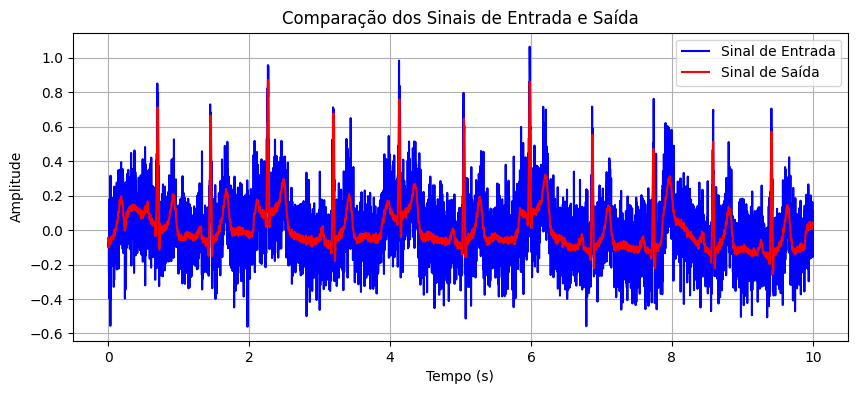

In [11]:
#Resposta da questão 3c
sinal = sp.io.loadmat('noisy_ecg_data_3.mat')['noisy_ecg_3'].ravel()

fs = 500
fc = 50

N = 41
h, _ = filtro_fir_centralizado(fs, fc, N)

output_signal = np.convolve(sinal, h, mode='same')
time = np.arange(len(sinal)) / fs

plt.figure(figsize=(10, 4))
plt.plot(time, sinal, color='b', label='Sinal de Entrada')
plt.plot(time, output_signal, color='r', label='Sinal de Saída')
plt.title('Comparação dos Sinais de Entrada e Saída')
plt.ylabel('Amplitude')
plt.xlabel('Tempo (s)')
plt.legend()
plt.grid()
plt.show()


## Questão 3d (1.0  ponto)

Utilize a técnica de *zero-phase filtering* com o filtro do item anterior. Compare a saída do sistema com e sem a aplicação da técnica.

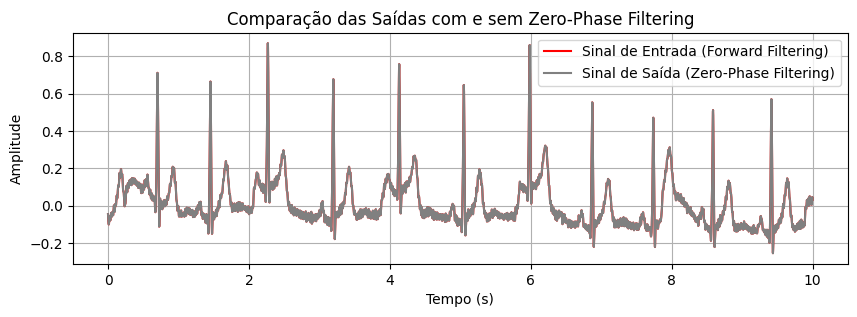

Erro Médio Absoluto (MAE): 4.753142324176451e-16


In [12]:
#Resposta da questão 3d
fs = 500
fc = 50

N = 41
h, _ = filtro_fir_centralizado(fs, fc, N)

saida_forward = np.convolve(sinal, h, mode='same')
saida_backward = np.convolve(sinal[::-1], h, mode='same')[::-1]

saida_zero_phase = (saida_forward + saida_backward) / 2

time = np.arange(len(sinal)) / fs

plt.figure(figsize=(10, 3))
plt.plot(time, saida_forward, color='r', label='Sinal de Entrada (Forward Filtering)')
plt.plot(time, saida_zero_phase, color='gray', label='Sinal de Saída (Zero-Phase Filtering)')
plt.title('Comparação das Saídas com e sem Zero-Phase Filtering')
plt.ylabel('Amplitude')
plt.xlabel('Tempo (s)')
plt.legend()
plt.grid()

plt.show()

MAE = 0
for i in range(N):
	MAE += abs(saida_forward[i] - saida_zero_phase[i])

print("Erro Médio Absoluto (MAE):", MAE)